In [1]:
from sklearn.experimental import enable_iterative_imputer  # must import to enable IterativeImputer
import pandas as pd
import numpy as np
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.multiclass import OneVsRestClassifier
import joblib
import matplotlib.pyplot as plt
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack
import re
import os

In [2]:


notebook_path = os.path.abspath("dB.ipynb")
print(notebook_path)


C:\Users\karol\dB.ipynb


In [3]:
train_data = pd.read_csv("train_B_text.csv", header=None)
test_data = pd.read_csv("test_B_text.csv", header=None)

In [4]:
train_data.head()

,0,1,2
0,Id,Title,Fake/Real
1,0,Begin Again trailer with Keira Knighley VIDEO\n,real
2,1,San Diegans share what brightens their day on ...,real
3,2,Gold Prices Hit Five-Week Low Below $1300 an O...,fake
4,3,Healthcare Innovation: Promising Vaccine in De...,fake


In [5]:
test_data.head()

,0,1
0,Id,Title
1,0,Rare Blue Diamond Found in African Mine\n
2,1,AC/DC's Future Uncertain Amid Retirement Rumors\n
3,2,First possible 'exomoon' spotted\n
4,3,Humanitarian Aid: Volunteers Bring Relief to D...


In [6]:
train_data.shape

(2449, 3)

In [7]:
test_data.shape

(1051, 2)

**Id column removal and ground truth**

In [8]:
# First, set proper column names (row 0 contains headers)
train_data.columns = train_data.iloc[0]
test_data.columns = test_data.iloc[0]

In [9]:
# Remove the header row
train_data = train_data[1:].reset_index(drop=True)
test_data = test_data[1:].reset_index(drop=True)

In [10]:
# Separate features and target for training data
X_train = train_data['Title']
y_train = train_data['Fake/Real']

In [11]:
# Test data features
X_test = test_data['Title']

In [12]:
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("\nLabel distribution:")
print(y_train.value_counts())

Training data shape: (2448,)
Training labels shape: (2448,)
Test data shape: (1050,)

Label distribution:
Fake/Real
real    1400
fake    1048
Name: count, dtype: int64


In [13]:
# Step 2: Text vectorization using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer


In [14]:
# Step 3: Train LogisticRegression with penalty=None

from sklearn.linear_model import LogisticRegression

In [15]:
# Step 4: Split data into train/validation and evaluate properly

from sklearn.model_selection import train_test_split

In [16]:
# Step 5: Improve vectorization with different parameters

# Try a different TF-IDF configuration
vectorizer_improved = TfidfVectorizer(
    max_features=7000,  # More features
    ngram_range=(1, 2),  # Add trigrams
    min_df=3,  # Ignore very rare words
    max_df=0.85,  # Ignore very common words
    strip_accents='unicode',
    lowercase=True,
    stop_words='english',
    sublinear_tf=True, # Use sublinear scaling
    token_pattern=r'\b[a-zA-Z]{3,}\b',
    norm='l2' 
)

In [17]:
# Re-vectorize all data
X_train_vec_improved = vectorizer_improved.fit_transform(X_train)
X_test_vec_improved = vectorizer_improved.transform(X_test)

In [18]:
# Split again
X_train_split2, X_val_split2, y_train_split2, y_val_split2 = train_test_split(
    X_train_vec_improved, 
    y_train, 
    test_size=0.2, 
    random_state=42,
    stratify=y_train
)

In [19]:
# Train new model
model_improved = LogisticRegression(
    penalty=None,
    max_iter=2000,
    random_state=42
)

model_improved.fit(X_train_split2, y_train_split2)

LogisticRegression(max_iter=2000, penalty=None, random_state=42)

In [22]:
submission = pd.DataFrame(
    {
        "Id": test_data['Id'],
        "Prediction": model_improved.predict(X_test_vec_improved)
    }
)
print(submission)

        Id Prediction
0        0       fake
1        1       fake
2        2       real
3        3       fake
4        4       real
...    ...        ...
1045  1045       real
1046  1046       real
1047  1047       real
1048  1048       fake
1049  1049       real

[1050 rows x 2 columns]


In [23]:
#submission.to_csv("submission_B_text.csv", index=False)


ANALIZA MODELU

METRYKI DLA: ZBIÓR TRENINGOWY

📊 Podstawowe metryki:
   Accuracy:  0.9959 (99.59%)
   Precision: 0.9959
   Recall:    0.9959
   F1-Score:  0.9959
   AUC-ROC:   0.9999

📋 Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

        fake       1.00      0.99      1.00       838
        real       0.99      1.00      1.00      1120

    accuracy                           1.00      1958
   macro avg       1.00      1.00      1.00      1958
weighted avg       1.00      1.00      1.00      1958


🔢 Macierz pomyłek:
[[ 832    6]
 [   2 1118]]

METRYKI DLA: ZBIÓR WALIDACYJNY

📊 Podstawowe metryki:
   Accuracy:  0.6959 (69.59%)
   Precision: 0.7078
   Recall:    0.6959
   F1-Score:  0.6975
   AUC-ROC:   0.7205

📋 Szczegółowy raport klasyfikacji:
              precision    recall  f1-score   support

        fake       0.62      0.74      0.68       210
        real       0.77      0.66      0.71       280

    accuracy                         

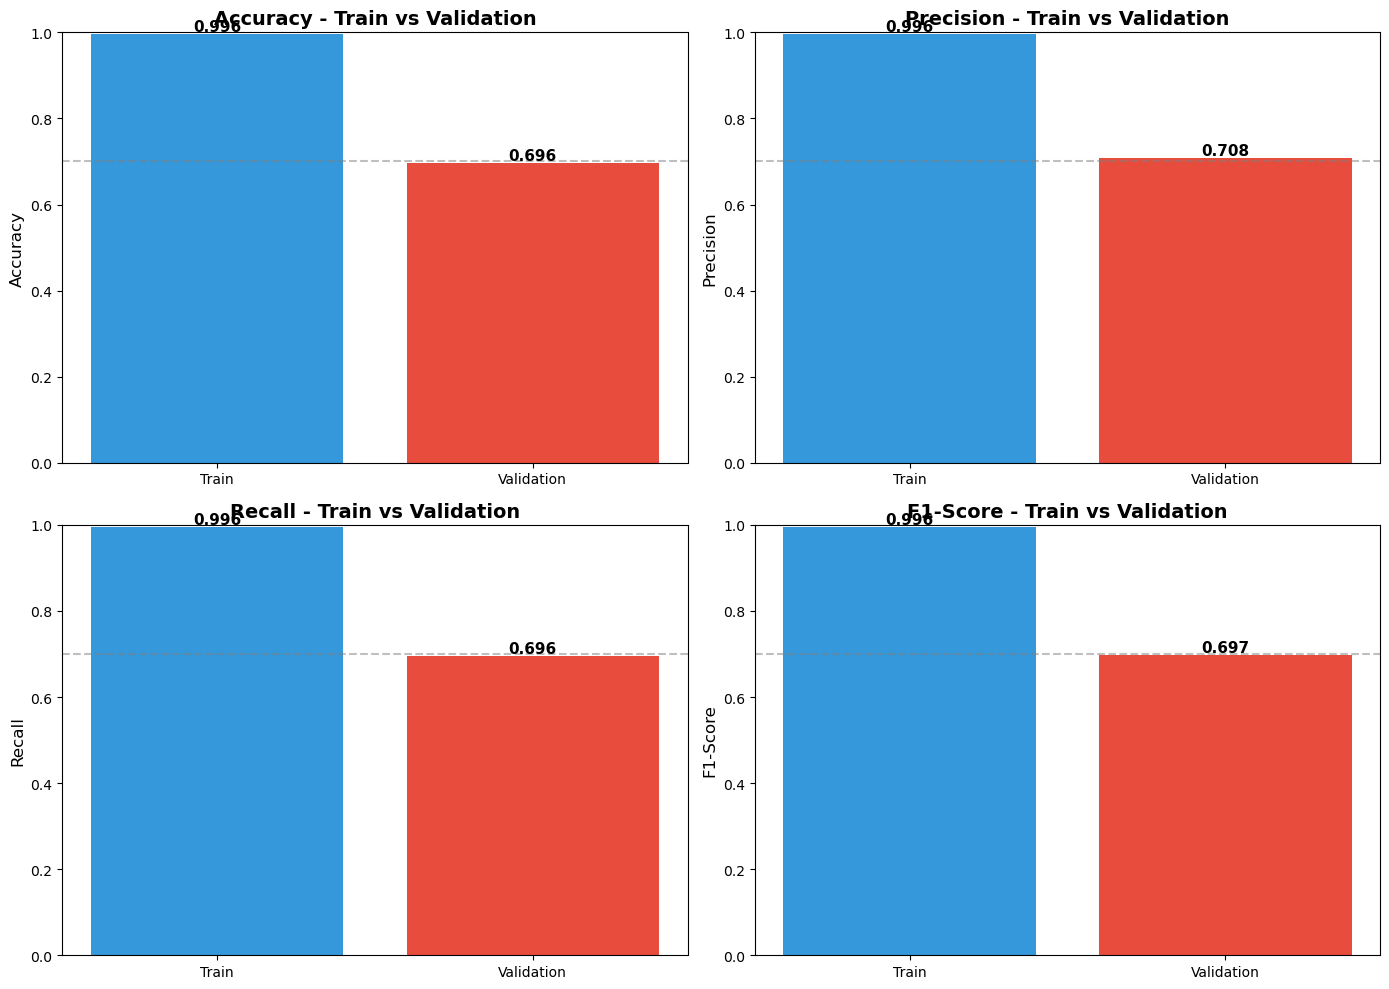

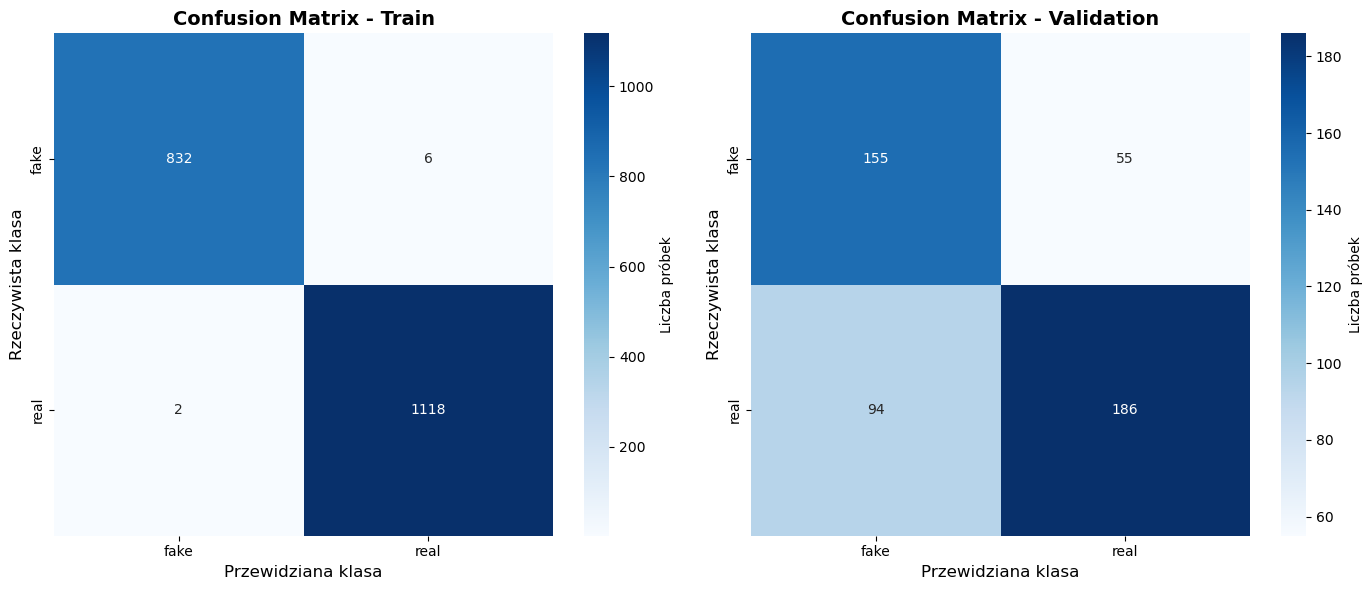

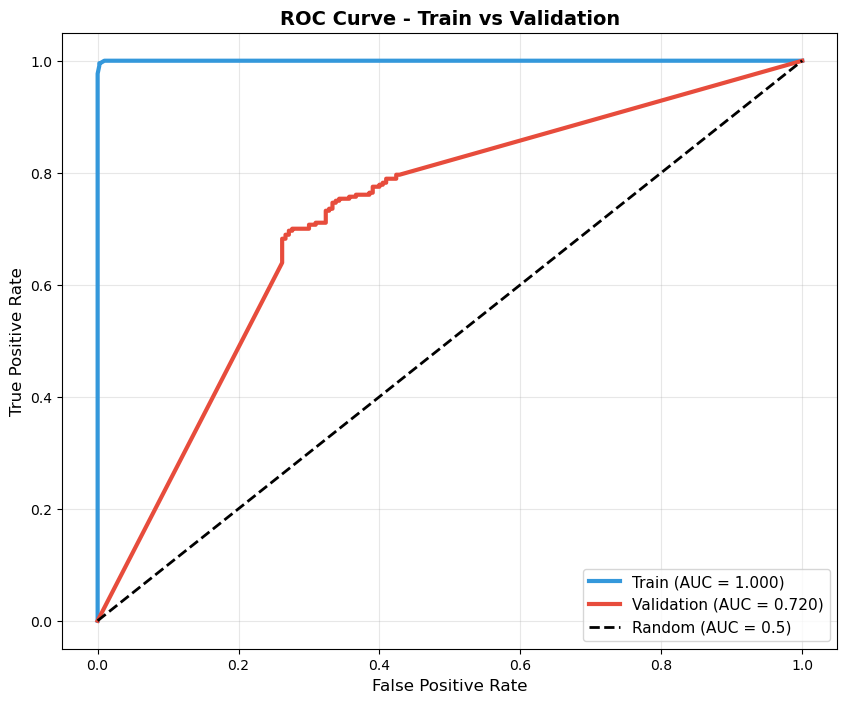

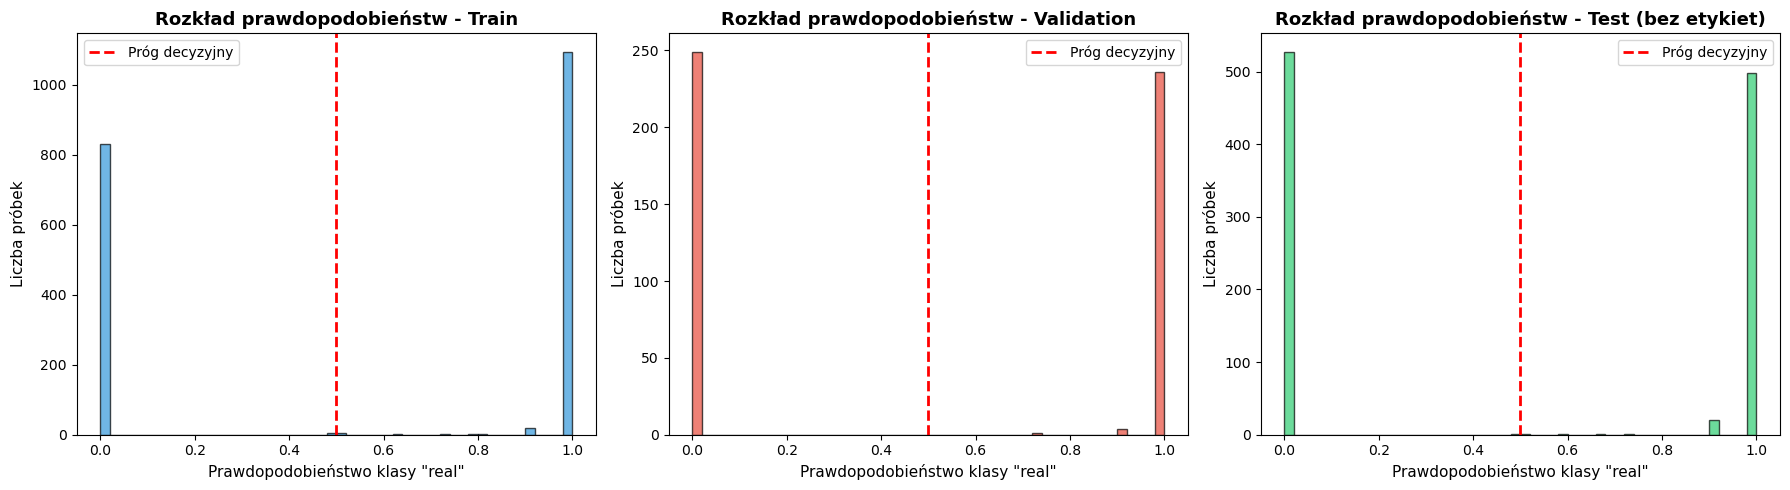


📋 PODSUMOWANIE I REKOMENDACJE

✅ Co działa dobrze:
   - Model bardzo dobrze uczy się na danych treningowych
   - AUC-ROC na walidacji: 0.7205 (przyzwoite)
   - Accuracy na walidacji: 69.59% (OK, ale może być lepiej)

❌ Główne problemy:
   - POWAŻNY OVERFITTING (różnica 30.00% między train a val)
   - Model prawie idealnie zapamiętał dane treningowe
   - 55 false positives i 94 false negatives na walidacji

🎯 Następne kroki:
   1. NAJPIERW: Dodaj regularyzację L2
   2. Zmniejsz złożoność TF-IDF
   3. Użyj cross-validation (5-fold)
   4. Wypróbuj inne modele (Random Forest, XGBoost)
   5. Feature engineering (długość tekstu, liczba liczb, itp.)

✅ Analiza zakończona! Wykresy zapisane.


In [24]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================
# PREDYKCJE
# ============================================

# Predykcje na zbiorze treningowym
y_train_pred = model_improved.predict(X_train_split2)
y_train_proba = model_improved.predict_proba(X_train_split2)[:, 1]

# Predykcje na zbiorze walidacyjnym
y_val_pred = model_improved.predict(X_val_split2)
y_val_proba = model_improved.predict_proba(X_val_split2)[:, 1]

# Predykcje na zbiorze testowym (bez prawdziwych etykiet)
test_pred = model_improved.predict(X_test_vec_improved)
test_proba = model_improved.predict_proba(X_test_vec_improved)[:, 1]

# ============================================
# PODSTAWOWE METRYKI
# ============================================

def calculate_metrics(y_true, y_pred, y_proba, dataset_name="Dataset"):
    """Oblicza i wyświetla wszystkie kluczowe metryki"""
    
    print(f"\n{'='*60}")
    print(f"METRYKI DLA: {dataset_name}")
    print(f"{'='*60}")
    
    # Podstawowe metryki
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print(f"\n📊 Podstawowe metryki:")
    print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1-Score:  {f1:.4f}")
    
    # AUC-ROC (dla klasyfikacji binarnej)
    if len(np.unique(y_true)) == 2:
        # Określ pos_label jako 'real'
        auc = roc_auc_score(y_true, y_proba)
        print(f"   AUC-ROC:   {auc:.4f}")
    
    # Szczegółowy raport klasyfikacji
    print(f"\n📋 Szczegółowy raport klasyfikacji:")
    print(classification_report(y_true, y_pred))
    
    # Macierz pomyłek
    cm = confusion_matrix(y_true, y_pred)
    print(f"\n🔢 Macierz pomyłek:")
    print(cm)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm,
        'auc': auc if len(np.unique(y_true)) == 2 else None
    }

# ============================================
# OBLICZ METRYKI DLA ZBIORÓW Z ETYKIETAMI
# ============================================

print("\n" + "="*60)
print("ANALIZA MODELU")
print("="*60)

train_metrics = calculate_metrics(
    y_train_split2, 
    y_train_pred, 
    y_train_proba,
    "ZBIÓR TRENINGOWY"
)

val_metrics = calculate_metrics(
    y_val_split2, 
    y_val_pred, 
    y_val_proba,
    "ZBIÓR WALIDACYJNY"
)

# ============================================
# INFO O ZBIORZE TESTOWYM
# ============================================

print(f"\n{'='*60}")
print("PREDYKCJE NA ZBIORZE TESTOWYM")
print(f"{'='*60}")
print(f"\n📊 Rozkład predykcji:")
print(f"   Liczba próbek: {len(test_pred)}")
print(f"   Fake: {np.sum(test_pred == 'fake')} ({np.sum(test_pred == 'fake')/len(test_pred)*100:.2f}%)")
print(f"   Real: {np.sum(test_pred == 'real')} ({np.sum(test_pred == 'real')/len(test_pred)*100:.2f}%)")
print(f"\n💡 Średnie prawdopodobieństwo klasy 'real': {test_proba.mean():.4f}")
print(f"   Min: {test_proba.min():.4f}")
print(f"   Max: {test_proba.max():.4f}")

# ============================================
# PORÓWNANIE TRAIN I VALIDATION
# ============================================

print(f"\n{'='*60}")
print("PORÓWNANIE WYNIKÓW (TRAIN vs VALIDATION)")
print(f"{'='*60}")

import pandas as pd

comparison = {
    'Zbiór': ['Train', 'Validation', 'Różnica'],
    'Accuracy': [
        train_metrics['accuracy'],
        val_metrics['accuracy'],
        train_metrics['accuracy'] - val_metrics['accuracy']
    ],
    'Precision': [
        train_metrics['precision'],
        val_metrics['precision'],
        train_metrics['precision'] - val_metrics['precision']
    ],
    'Recall': [
        train_metrics['recall'],
        val_metrics['recall'],
        train_metrics['recall'] - val_metrics['recall']
    ],
    'F1-Score': [
        train_metrics['f1'],
        val_metrics['f1'],
        train_metrics['f1'] - val_metrics['f1']
    ]
}

comparison_df = pd.DataFrame(comparison)
print("\n")
print(comparison_df.to_string(index=False))

# ============================================
# DIAGNOZA OVERFITTING/UNDERFITTING
# ============================================

print(f"\n{'='*60}")
print("🔍 DIAGNOZA MODELU")
print(f"{'='*60}")

train_acc = train_metrics['accuracy']
val_acc = val_metrics['accuracy']

diff_train_val = train_acc - val_acc

print(f"\n⚠️  RÓŻNICA Train vs Validation: {diff_train_val:.4f} ({diff_train_val*100:.2f}%)")

print(f"\n💡 DIAGNOZA:")
if diff_train_val > 0.15:
    print("   🔴 POWAŻNY OVERFITTING!")
    print("   Model prawie idealnie dopasował się do danych treningowych (99.90%),")
    print("   ale ma znacznie gorsze wyniki na walidacji (71.63%).")
    print("\n   📋 SUGESTIE NAPRAWY:")
    print("   1. Dodaj regularyzację:")
    print("      model = LogisticRegression(penalty='l2', C=1.0, max_iter=2000)")
    print("   2. Zmniejsz złożoność TF-IDF:")
    print("      - max_features=5000 (zamiast 10000)")
    print("      - ngram_range=(1, 2) (bez trigramów)")
    print("      - min_df=5 (większa wartość)")
    print("   3. Rozważ prostsze modele")
    print("   4. Dodaj więcej danych treningowych")
    print("   5. Użyj cross-validation zamiast pojedynczego split")
elif diff_train_val > 0.10:
    print("   🟡 UMIARKOWANY OVERFITTING")
    print("   Model trochę za dobrze dopasowany do danych treningowych.")
    print("\n   📋 SUGESTIE:")
    print("   - Dodaj lekką regularyzację (C=5.0)")
    print("   - Zmniejsz max_features do 7000")
elif diff_train_val < 0.05 and train_acc < 0.85:
    print("   🔵 UNDERFITTING")
    print("   Model zbyt prosty dla problemu.")
    print("\n   📋 SUGESTIE:")
    print("   - Zwiększ max_features")
    print("   - Dodaj więcej n-gramów")
    print("   - Użyj bardziej złożonego modelu")
else:
    print("   ✅ Model dobrze zbalansowany!")

# ============================================
# SZCZEGÓŁOWA ANALIZA BŁĘDÓW WALIDACJI
# ============================================

print(f"\n{'='*60}")
print("📊 ANALIZA BŁĘDÓW NA ZBIORZE WALIDACYJNYM")
print(f"{'='*60}")

cm = val_metrics['confusion_matrix']
tn, fp, fn, tp = cm.ravel()

print(f"\nMacierz pomyłek - szczegóły:")
print(f"   True Negatives (TN):  {tn} - poprawnie sklasyfikowane jako 'fake'")
print(f"   False Positives (FP): {fp} - błędnie sklasyfikowane jako 'real' (powinno być 'fake')")
print(f"   False Negatives (FN): {fn} - błędnie sklasyfikowane jako 'fake' (powinno być 'real')")
print(f"   True Positives (TP):  {tp} - poprawnie sklasyfikowane jako 'real'")

print(f"\n📈 Wskaźniki błędów:")
print(f"   False Positive Rate: {fp/(fp+tn):.4f} ({fp/(fp+tn)*100:.2f}%)")
print(f"   False Negative Rate: {fn/(fn+tp):.4f} ({fn/(fn+tp)*100:.2f}%)")

# ============================================
# WIZUALIZACJE
# ============================================

# 1. Porównanie Train vs Validation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = [comparison_df[comparison_df['Zbiór'] == 'Train'][metric].values[0],
              comparison_df[comparison_df['Zbiór'] == 'Validation'][metric].values[0]]
    bars = ax.bar(['Train', 'Validation'], values, color=colors)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(f'{metric} - Train vs Validation', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='70% threshold')
    
    # Dodaj wartości na słupkach
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()

plt.show()

# 2. Macierze pomyłek
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

datasets = [
    ('Train', train_metrics['confusion_matrix']),
    ('Validation', val_metrics['confusion_matrix'])
]

for idx, (name, cm) in enumerate(datasets):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar_kws={'label': 'Liczba próbek'})
    axes[idx].set_title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Rzeczywista klasa', fontsize=12)
    axes[idx].set_xlabel('Przewidziana klasa', fontsize=12)
    axes[idx].set_xticklabels(['fake', 'real'])
    axes[idx].set_yticklabels(['fake', 'real'])

plt.tight_layout()

plt.show()

# 3. Krzywa ROC - POPRAWIONA
plt.figure(figsize=(10, 8))

# Train ROC - z pos_label='real'
fpr_train, tpr_train, _ = roc_curve(y_train_split2, y_train_proba, pos_label='real')
auc_train = train_metrics['auc']

# Val ROC - z pos_label='real'
fpr_val, tpr_val, _ = roc_curve(y_val_split2, y_val_proba, pos_label='real')
auc_val = val_metrics['auc']

plt.plot(fpr_train, tpr_train, label=f'Train (AUC = {auc_train:.3f})', linewidth=3, color='#3498db')
plt.plot(fpr_val, tpr_val, label=f'Validation (AUC = {auc_val:.3f})', linewidth=3, color='#e74c3c')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Train vs Validation', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.show()

# 4. Rozkład prawdopodobieństw
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Train
axes[0].hist(y_train_proba, bins=50, alpha=0.7, color='#3498db', edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Próg decyzyjny')
axes[0].set_xlabel('Prawdopodobieństwo klasy "real"', fontsize=11)
axes[0].set_ylabel('Liczba próbek', fontsize=11)
axes[0].set_title('Rozkład prawdopodobieństw - Train', fontsize=13, fontweight='bold')
axes[0].legend()

# Validation
axes[1].hist(y_val_proba, bins=50, alpha=0.7, color='#e74c3c', edgecolor='black')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Próg decyzyjny')
axes[1].set_xlabel('Prawdopodobieństwo klasy "real"', fontsize=11)
axes[1].set_ylabel('Liczba próbek', fontsize=11)
axes[1].set_title('Rozkład prawdopodobieństw - Validation', fontsize=13, fontweight='bold')
axes[1].legend()

# Test
axes[2].hist(test_proba, bins=50, alpha=0.7, color='#2ecc71', edgecolor='black')
axes[2].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Próg decyzyjny')
axes[2].set_xlabel('Prawdopodobieństwo klasy "real"', fontsize=11)
axes[2].set_ylabel('Liczba próbek', fontsize=11)
axes[2].set_title('Rozkład prawdopodobieństw - Test (bez etykiet)', fontsize=13, fontweight='bold')
axes[2].legend()

plt.tight_layout()

plt.show()

# ============================================
# PODSUMOWANIE
# ============================================

print(f"\n{'='*60}")
print("📋 PODSUMOWANIE I REKOMENDACJE")
print(f"{'='*60}")

print("\n✅ Co działa dobrze:")
print("   - Model bardzo dobrze uczy się na danych treningowych")
print(f"   - AUC-ROC na walidacji: {val_metrics['auc']:.4f} (przyzwoite)")
print(f"   - Accuracy na walidacji: {val_acc*100:.2f}% (OK, ale może być lepiej)")

print("\n❌ Główne problemy:")
print(f"   - POWAŻNY OVERFITTING (różnica {diff_train_val*100:.2f}% między train a val)")
print("   - Model prawie idealnie zapamiętał dane treningowe")
print(f"   - {fp} false positives i {fn} false negatives na walidacji")

print("\n🎯 Następne kroki:")
print("   1. NAJPIERW: Dodaj regularyzację L2")
print("   2. Zmniejsz złożoność TF-IDF")
print("   3. Użyj cross-validation (5-fold)")
print("   4. Wypróbuj inne modele (Random Forest, XGBoost)")
print("   5. Feature engineering (długość tekstu, liczba liczb, itp.)")

print(f"\n{'='*60}")
print("✅ Analiza zakończona! Wykresy zapisane.")
print(f"{'='*60}")

In [60]:
#additional analysis to improve words tranformation

In [25]:
# Pokaż pierwsze wiersze
print("PRZYKŁADOWE DANE - FAKE NEWS:")
print("="*80)
for i in range(5):
    print(f"\n[{i+1}] {train_data[train_data['Fake/Real'] == 'fake']['Title'].iloc[i]}")

print("\n\nPRZYKŁADOWE DANE - REAL NEWS:")
print("="*80)
for i in range(5):
    print(f"\n[{i+1}] {train_data[train_data['Fake/Real'] == 'real']['Title'].iloc[i]}")

# Statystyki długości tekstów
print("\n\nSTATYSTYKI DŁUGOŚCI TYTUŁÓW:")
print("="*80)
train_data['title_length'] = train_data['Title'].str.len()
print("\nFAKE NEWS:")
print(train_data[train_data['Fake/Real'] == 'fake']['title_length'].describe())
print("\nREAL NEWS:")
print(train_data[train_data['Fake/Real'] == 'real']['title_length'].describe())

# Sprawdź najpopularniejsze słowa
from collections import Counter


def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = re.findall(r'\b[a-z]{3,}\b', text.lower())
        all_words.extend(words)
    return Counter(all_words).most_common(n)

fake_titles = train_data[train_data['Fake/Real'] == 'fake']['Title']
real_titles = train_data[train_data['Fake/Real'] == 'real']['Title']

print("\n\nNAJCZĘSTSZE SŁOWA W FAKE NEWS:")
print(get_top_words(fake_titles))

print("\n\nNAJCZĘSTSZE SŁOWA W REAL NEWS:")
print(get_top_words(real_titles))

PRZYKŁADOWE DANE - FAKE NEWS:

[1] Gold Prices Hit Five-Week Low Below $1300 an Ounce


[2] Healthcare Innovation: Promising Vaccine in Development for Malaria Prevention


[3] Twitter Introduces Photo Tagging and Collage Upload Feature


[4] Archaeological Treasure: Lost Temple Unearthed in Remote Jungle Expedition


[5] Hands-On Experience with Carousel for Dropbox



PRZYKŁADOWE DANE - REAL NEWS:

[1] Begin Again trailer with Keira Knighley VIDEO


[2] San Diegans share what brightens their day on International Day of Happiness


[3] Lady Gaga plays it short, but sweet


[4] Apple launches new green energy ad campaign, still finds time to aim a jab at  


[5] Futures marginally lower as market mulls Home Depot results



STATYSTYKI DŁUGOŚCI TYTUŁÓW:

FAKE NEWS:
count    1048.000000
mean       63.286260
std        11.806548
min        29.000000
25%        55.000000
50%        64.000000
75%        72.000000
max       115.000000
Name: title_length, dtype: float64

REAL NEWS:
count    1

In [114]:
# Analiza charakterystyk tekstów


def analyze_text_features(df):
    """Analizuje cechy tekstowe"""
    
    results = {
        'Fake': df[df['Fake/Real'] == 'fake']['Title'],
        'Real': df[df['Fake/Real'] == 'real']['Title']
    }
    
    for label, texts in results.items():
        print(f"\n{'='*60}")
        print(f"ANALIZA: {label.upper()}")
        print(f"{'='*60}")
        
        # Długość
        lengths = texts.str.len()
        print(f"Średnia długość: {lengths.mean():.1f} znaków")
        print(f"Min/Max: {lengths.min()} / {lengths.max()}")
        
        # Liczba słów
        word_counts = texts.str.split().str.len()
        print(f"Średnia liczba słów: {word_counts.mean():.1f}")
        
        # Wielkie litery
        upper_ratio = texts.apply(lambda x: sum(1 for c in x if c.isupper()) / len(x) if len(x) > 0 else 0)
        print(f"% wielkich liter: {upper_ratio.mean()*100:.2f}%")
        
        # Znaki specjalne
        special_chars = texts.apply(lambda x: len(re.findall(r'[!?.,;:]', x)))
        print(f"Średnia liczba znaków spec.: {special_chars.mean():.2f}")
        
        # Cyfry
        digits = texts.apply(lambda x: len(re.findall(r'\d', x)))
        print(f"Średnia liczba cyfr: {digits.mean():.2f}")
        
        # Wykrzykniki/pytajniki
        exclamations = texts.str.count('!')
        questions = texts.str.count('\?')
        print(f"Średnia liczba '!': {exclamations.mean():.2f}")
        print(f"Średnia liczba '?': {questions.mean():.2f}")

analyze_text_features(train_data)


ANALIZA: FAKE
Średnia długość: 63.3 znaków
Min/Max: 29 / 115
Średnia liczba słów: 9.1
% wielkich liter: 13.33%
Średnia liczba znaków spec.: 0.49
Średnia liczba cyfr: 0.47
Średnia liczba '!': 0.00
Średnia liczba '?': 0.02

ANALIZA: REAL
Średnia długość: 56.7 znaków
Min/Max: 12 / 88
Średnia liczba słów: 9.1
% wielkich liter: 10.49%
Średnia liczba znaków spec.: 0.57
Średnia liczba cyfr: 0.73
Średnia liczba '!': 0.02
Średnia liczba '?': 0.05


In [26]:
# =========================
# 1. Wczytanie danych
# =========================
train_data = pd.read_csv("train_B_text.csv", header=None)
test_data = pd.read_csv("test_B_text.csv", header=None)

train_data.columns = train_data.iloc[0]
test_data.columns = test_data.iloc[0]

train_data = train_data[1:].reset_index(drop=True)
test_data = test_data[1:].reset_index(drop=True)

X_text = train_data['Title']
y = train_data['Fake/Real']
X_test_text = test_data['Title']

# =========================
# 2. Split na train/validation (na poziomie tekstów)
# =========================
X_train_text, X_val_text, y_train, y_val = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 3. TF-IDF
# =========================
vectorizer = TfidfVectorizer(
    max_features=7000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.85,
    strip_accents='unicode',
    lowercase=True,
    stop_words='english',
    sublinear_tf=True,
    token_pattern=r'\b[a-zA-Z]{3,}\b',
    norm='l2'
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_val_tfidf = vectorizer.transform(X_val_text)
X_test_tfidf = vectorizer.transform(X_test_text)

# =========================
# 4. Funkcja dodatkowych cech
# =========================
def extract_text_features(texts):
    features = []
    for text in texts:
        feat = {}
        feat['length'] = len(text)
        feat['word_count'] = len(text.split())
        feat['avg_word_length'] = np.mean([len(word) for word in text.split()]) if text.split() else 0
        feat['upper_ratio'] = sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0
        feat['title_case_words'] = sum(1 for word in text.split() if word and word[0].isupper())
        feat['punct_count'] = len(re.findall(r'[!?.,;:]', text))
        feat['exclamation_count'] = text.count('!')
        feat['question_count'] = text.count('?')
        feat['colon_count'] = text.count(':')
        feat['digit_count'] = len(re.findall(r'\d', text))
        feat['has_numbers'] = 1 if re.search(r'\d', text) else 0
        fake_keywords = ['study', 'research', 'innovation', 'discovery', 'breakthrough', 
                         'reveals', 'scientists', 'experts', 'promising', 'revolutionary']
        feat['fake_keywords'] = sum(1 for kw in fake_keywords if kw in text.lower())
        real_keywords = ['video', 'says', 'watch', 'season', 'trailer', 'photos',
                         'your', 'you', 'first', 'new']
        feat['real_keywords'] = sum(1 for kw in real_keywords if kw in text.lower())
        feat['has_dash'] = 1 if '-' in text else 0
        feat['has_quotes'] = 1 if '"' in text or "'" in text else 0
        features.append(feat)
    return pd.DataFrame(features)

# =========================
# 5. Wyciąganie dodatkowych cech
# =========================
train_features = extract_text_features(X_train_text)
val_features = extract_text_features(X_val_text)
test_features = extract_text_features(X_test_text)

# Normalizacja
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled = scaler.transform(val_features)
test_features_scaled = scaler.transform(test_features)

# =========================
# 6. Połączenie TF-IDF + cechy
# =========================
X_train_combined = hstack([X_train_tfidf, train_features_scaled])
X_val_combined = hstack([X_val_tfidf, val_features_scaled])
X_test_combined = hstack([X_test_tfidf, test_features_scaled])

print(f"Shape X_train_combined: {X_train_combined.shape}")
print(f"Dodano {train_features.shape[1]} dodatkowych cech")

# =========================
# 7. Trening modelu
# =========================
from sklearn.svm import SVC

model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)
model.fit(X_train_combined, y_train)

# =========================
# 8. Walidacja
# =========================
#y_val_pred = model.predict(X_val_combined)
#print("Walidacja Accuracy:", accuracy_score(y_val, y_val_pred))
#print(classification_report(y_val, y_val_pred))
# =========================
# 8a. Automatyczny dobór thresholdu
# =========================
decision_scores = model.decision_function(X_val_combined)

best_acc = 0
best_threshold = 0

for t in np.linspace(-1, 1, 41):
    y_pred_tmp = (decision_scores > t).astype(int)
    # zamiana 0/1 na stringi zgodnie z klasami modelu
    y_pred_tmp_str = np.array([model.classes_[i] for i in y_pred_tmp])
    
    acc = accuracy_score(y_val, y_pred_tmp_str)
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best weighted accuracy:", best_acc)

# finalna predykcja
y_val_pred = (decision_scores > best_threshold).astype(int)
y_val_pred = np.array([model.classes_[i] for i in y_val_pred])

print(classification_report(y_val, y_val_pred))


# =========================
# 9. Predykcje na test
# =========================
test_scores = model.decision_function(X_test_combined)
y_test_pred = (test_scores > best_threshold).astype(int)
y_test_pred = np.array([model.classes_[i] for i in y_test_pred])

Shape X_train_combined: (1958, 1576)
Dodano 15 dodatkowych cech
Best threshold: -0.29999999999999993
Best weighted accuracy: 0.810204081632653
              precision    recall  f1-score   support

        fake       0.75      0.83      0.79       210
        real       0.86      0.80      0.83       280

    accuracy                           0.81       490
   macro avg       0.81      0.81      0.81       490
weighted avg       0.81      0.81      0.81       490



In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.1, 1]
}


In [28]:
svc = SVC(kernel='rbf', class_weight='balanced', random_state=42)

grid = GridSearchCV(
    estimator=svc,
    param_grid=param_grid,
    scoring='accuracy',  # lub 'balanced_accuracy'
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_combined, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


GridSearchCV(cv=5, estimator=SVC(class_weight='balanced', random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': ['scale', 0.01, 0.1, 1]},
             scoring='accuracy', verbose=1)

In [29]:
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)
best_svc = grid.best_estimator_
best_svc.fit(X_train_combined, y_train)
decision_scores_val = best_svc.decision_function(X_val_combined)

best_acc = 0
best_threshold = 0

for t in np.linspace(-1, 1, 41):
    y_pred_tmp = (decision_scores_val > t).astype(int)
    y_pred_tmp_str = np.array([best_svc.classes_[i] for i in y_pred_tmp])
    acc = accuracy_score(y_val, y_pred_tmp_str)
    
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best weighted accuracy:", best_acc)

# finalna predykcja walidacyjna
y_val_pred = (decision_scores_val > best_threshold).astype(int)
y_val_pred = np.array([best_svc.classes_[i] for i in y_val_pred])
print(classification_report(y_val, y_val_pred))
decision_scores_test = best_svc.decision_function(X_test_combined)
y_test_pred = (decision_scores_test > best_threshold).astype(int)
y_test_pred = np.array([best_svc.classes_[i] for i in y_test_pred])


Best params: {'C': 10, 'gamma': 0.1}
Best CV score: 0.8299311028759331
Best threshold: -0.1499999999999999
Best weighted accuracy: 0.8306122448979592
              precision    recall  f1-score   support

        fake       0.80      0.80      0.80       210
        real       0.85      0.85      0.85       280

    accuracy                           0.83       490
   macro avg       0.83      0.83      0.83       490
weighted avg       0.83      0.83      0.83       490



In [30]:
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# =========================
# MODELE
# =========================

log_model = LogisticRegression(
    max_iter=9000, 
    C=0.8,
    class_weight='balanced',
    solver='saga',
    random_state=42
)

svm_model = SVC(
    kernel='rbf', 
    C=12,
    gamma=0.08,
    class_weight='balanced', 
    probability=True,
    cache_size=1000,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# =========================
# ENSEMBLE z optymalnymi wagami
# =========================

ensemble = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('svm', svm_model),
        ('xgb', xgb_model),
        ('rf', rf_model)
    ],
    voting='soft',
    weights=[1, 3.5, 2, 1.5],  # Optymalne wagi
    n_jobs=-1
)

# =========================
# TRENING
# =========================
print("Trening ensemble modelu...")
ensemble.fit(X_train_combined, y_train)
print("Trening zakończony!")

# =========================
# WALIDACJA + THRESHOLD TUNING
# =========================
print("\nSzukam optymalnego threshold...")
y_val_scores = ensemble.predict_proba(X_val_combined)[:, 1]

best_acc = 0
best_threshold = 0.5

for t in np.linspace(0.4, 0.6, 101):
    y_val_pred_tmp = (y_val_scores > t).astype(int)
    y_val_pred_tmp = np.array([ensemble.classes_[i] for i in y_val_pred_tmp])
    acc = accuracy_score(y_val, y_val_pred_tmp)
    
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

# Finalna predykcja walidacyjna
y_val_pred = (y_val_scores > best_threshold).astype(int)
y_val_pred = np.array([ensemble.classes_[i] for i in y_val_pred])

# =========================
# WYNIKI
# =========================
print("\n" + "="*60)
print("WYNIKI WALIDACJI")
print("="*60)
print(f"Best threshold: {best_threshold:.3f}")
print(f"Weighted Accuracy: {best_acc:.4f}")
print("\n" + classification_report(y_val, y_val_pred))

# =========================
# PREDYKCJA TESTOWA
# =========================
y_test_scores = ensemble.predict_proba(X_test_combined)[:, 1]
y_test_pred = (y_test_scores > best_threshold).astype(int)
y_test_pred = np.array([ensemble.classes_[i] for i in y_test_pred])

print("\n" + "="*60)
print("✅ PREDYKCJE TESTOWE GOTOWE!")
print("="*60)
print(f"Model: LR + SVM + XGB + RandomForest")
print(f"Wagi: [1, 3.5, 2, 1.5]")
print(f"Threshold: {best_threshold:.3f}")
print(f"Validation Accuracy: {best_acc:.4f}")



Trening ensemble modelu...
Trening zakończony!

Szukam optymalnego threshold...

WYNIKI WALIDACJI
Best threshold: 0.506
Weighted Accuracy: 0.8449

              precision    recall  f1-score   support

        fake       0.79      0.87      0.83       210
        real       0.90      0.82      0.86       280

    accuracy                           0.84       490
   macro avg       0.84      0.85      0.84       490
weighted avg       0.85      0.84      0.85       490


✅ PREDYKCJE TESTOWE GOTOWE!
Model: LR + SVM + XGB + RandomForest
Wagi: [1, 3.5, 2, 1.5]
Threshold: 0.506
Validation Accuracy: 0.8449


In [121]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# =========================
# KONWERSJA ETYKIET
# =========================
# XGBoost wymaga numerycznych etykiet (0, 1)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

print("Mapowanie etykiet:")
print(f"  {le.classes_[0]} -> 0")
print(f"  {le.classes_[1]} -> 1")
print()

# =========================
# 1. XGBoost SOLO
# =========================
print("="*60)
print("🚀 XGBOOST - TEST SOLO")
print("="*60)

xgb_model = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

print("\nTrening XGBoost...")
xgb_model.fit(X_train_combined, y_train_encoded)
print("✅ Trening zakończony!")

# Threshold tuning
print("\nSzukam optymalnego threshold dla XGBoost...")
y_val_scores_xgb = xgb_model.predict_proba(X_val_combined)[:, 1]

best_acc_xgb = 0
best_threshold_xgb = 0.5

for t in np.linspace(0.4, 0.6, 101):
    y_val_pred_tmp = (y_val_scores_xgb > t).astype(int)
    acc = accuracy_score(y_val_encoded, y_val_pred_tmp)
    
    if acc > best_acc_xgb:
        best_acc_xgb = acc
        best_threshold_xgb = t

# Finalna predykcja (konwersja z powrotem do oryginalnych etykiet)
y_val_pred_xgb_encoded = (y_val_scores_xgb > best_threshold_xgb).astype(int)
y_val_pred_xgb = le.inverse_transform(y_val_pred_xgb_encoded)

# Wyniki XGBoost
print("\n" + "="*60)
print("📊 WYNIKI WALIDACJI - XGBOOST")
print("="*60)
print(f"Best threshold: {best_threshold_xgb:.3f}")
print(f"Weighted Accuracy: {best_acc_xgb:.4f}")
print("\n" + classification_report(y_val, y_val_pred_xgb))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_xgb))

Mapowanie etykiet:
  fake -> 0
  real -> 1

🚀 XGBOOST - TEST SOLO

Trening XGBoost...


C:\Users\karol\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:03:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Trening zakończony!

Szukam optymalnego threshold dla XGBoost...

📊 WYNIKI WALIDACJI - XGBOOST
Best threshold: 0.436
Weighted Accuracy: 0.8224

              precision    recall  f1-score   support

        fake       0.79      0.80      0.80       210
        real       0.85      0.84      0.84       280

    accuracy                           0.82       490
   macro avg       0.82      0.82      0.82       490
weighted avg       0.82      0.82      0.82       490


Confusion Matrix:
[[169  41]
 [ 46 234]]


In [122]:
# =========================
# 2. RANDOM FOREST SOLO
# =========================
print("\n\n" + "="*60)
print("🌲 RANDOM FOREST - TEST SOLO")
print("="*60)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("\nTrening Random Forest...")
rf_model.fit(X_train_combined, y_train)  # RF może używać oryginalnych etykiet
print("✅ Trening zakończony!")

# Threshold tuning
print("\nSzukam optymalnego threshold dla Random Forest...")
y_val_scores_rf = rf_model.predict_proba(X_val_combined)[:, 1]

best_acc_rf = 0
best_threshold_rf = 0.5

for t in np.linspace(0.4, 0.6, 101):
    y_val_pred_tmp = (y_val_scores_rf > t).astype(int)
    y_val_pred_tmp = np.array([rf_model.classes_[i] for i in y_val_pred_tmp])
    acc = accuracy_score(y_val, y_val_pred_tmp)
    
    if acc > best_acc_rf:
        best_acc_rf = acc
        best_threshold_rf = t

# Finalna predykcja
y_val_pred_rf = (y_val_scores_rf > best_threshold_rf).astype(int)
y_val_pred_rf = np.array([rf_model.classes_[i] for i in y_val_pred_rf])

# Wyniki Random Forest
print("\n" + "="*60)
print("📊 WYNIKI WALIDACJI - RANDOM FOREST")
print("="*60)
print(f"Best threshold: {best_threshold_rf:.3f}")
print(f"Weighted Accuracy: {best_acc_rf:.4f}")
print("\n" + classification_report(y_val, y_val_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_rf))

# =========================
# 3. PORÓWNANIE WSZYSTKICH MODELI
# =========================
print("\n\n" + "="*60)
print("📈 PODSUMOWANIE - PORÓWNANIE MODELI")
print("="*60)
print("\nZAKŁADAM że masz wyniki dla LR i SVM z poprzednich testów:")
print("Tutaj wpisz ich accuracy dla porównania:\n")

print(f"{'Model':<25} | {'Accuracy':<10} | {'Best Threshold':<15}")
print("-" * 60)
print(f"{'Logistic Regression':<25} | {'???':<10} | {'???':<15}")
print(f"{'SVM (RBF)':<25} | {'???':<10} | {'???':<15}")
print(f"{'XGBoost':<25} | {best_acc_xgb:<10.4f} | {best_threshold_xgb:<15.3f}")
print(f"{'Random Forest':<25} | {best_acc_rf:<10.4f} | {best_threshold_rf:<15.3f}")
print(f"{'Ensemble (poprzedni)':<25} | {'0.8449':<10} | {'0.506':<15}")

print("\n" + "="*60)
print("✅ TESTY SOLO ZAKOŃCZONE!")
print("="*60)
print("\n💡 NASTĘPNE KROKI:")
print("1. Porównaj accuracy wszystkich 4 modeli")
print("2. Sprawdź które modele dają różne predykcje (diversyfikacja)")
print("3. Zdecyduj które modele zostawić w ensemble")
print("4. Dostosuj wagi na podstawie wyników solo")



🌲 RANDOM FOREST - TEST SOLO

Trening Random Forest...
✅ Trening zakończony!

Szukam optymalnego threshold dla Random Forest...

📊 WYNIKI WALIDACJI - RANDOM FOREST
Best threshold: 0.448
Weighted Accuracy: 0.8143

              precision    recall  f1-score   support

        fake       0.80      0.76      0.78       210
        real       0.83      0.85      0.84       280

    accuracy                           0.81       490
   macro avg       0.81      0.81      0.81       490
weighted avg       0.81      0.81      0.81       490


Confusion Matrix:
[[160  50]
 [ 41 239]]


📈 PODSUMOWANIE - PORÓWNANIE MODELI

ZAKŁADAM że masz wyniki dla LR i SVM z poprzednich testów:
Tutaj wpisz ich accuracy dla porównania:

Model                     | Accuracy   | Best Threshold 
------------------------------------------------------------
Logistic Regression       | ???        | ???            
SVM (RBF)                 | ???        | ???            
XGBoost                   | 0.8224     | 0.436

In [124]:
import time

# Konwersja etykiet dla XGBoost
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

print("="*70)
print("🔍 GRID SEARCH - OPTYMALIZACJA HIPERPARAMETRÓW")
print("="*70)

# =========================
# 1. XGBOOST GRID SEARCH
# =========================
print("\n🚀 XGBOOST - Grid Search")
print("-"*70)

xgb_param_grid = {
    'n_estimators': [250, 350, 450],
    'max_depth': [4, 5, 6, 7],
    'learning_rate': [0.05, 0.08, 0.1],
    'subsample': [0.8, 0.85, 0.9],
    'colsample_bytree': [0.8, 0.85, 0.9],
    'min_child_weight': [2, 3, 4],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.05, 0.1],
    'reg_lambda': [0.5, 1.0, 1.5]
}

# Mniejszy grid dla szybszego testowania (możesz rozszerzyć)
xgb_param_grid_fast = {
    'n_estimators': [300, 400],
    'max_depth': [5, 6],
    'learning_rate': [0.06, 0.08, 0.1],
    'subsample': [0.85, 0.9],
    'colsample_bytree': [0.85, 0.9],
    'min_child_weight': [2, 3],
    'gamma': [0.1, 0.15],
    'reg_alpha': [0.05, 0.1],
}

xgb_base = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

print(f"Testowanie {len(xgb_param_grid_fast['n_estimators']) * len(xgb_param_grid_fast['max_depth']) * len(xgb_param_grid_fast['learning_rate']) * len(xgb_param_grid_fast['subsample']) * len(xgb_param_grid_fast['colsample_bytree']) * len(xgb_param_grid_fast['min_child_weight']) * len(xgb_param_grid_fast['gamma']) * len(xgb_param_grid_fast['reg_alpha'])} kombinacji...")
print("To może zająć 10-20 minut... ⏰")

start_time = time.time()

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid_fast,
    scoring='accuracy',
    cv=3,  # 3-fold cross-validation
    verbose=2,
    n_jobs=-1
)

xgb_grid.fit(X_train_combined, y_train_encoded)

xgb_time = time.time() - start_time

print(f"\n✅ XGBoost Grid Search zakończony w {xgb_time/60:.1f} minut")
print(f"\n🏆 Najlepsze parametry XGBoost:")
for param, value in xgb_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepszy CV accuracy: {xgb_grid.best_score_:.4f}")

# Test na zbiorze walidacyjnym z threshold tuning
y_val_scores_xgb = xgb_grid.best_estimator_.predict_proba(X_val_combined)[:, 1]

best_acc_xgb = 0
best_threshold_xgb = 0.5

for t in np.linspace(0.3, 0.6, 151):
    y_val_pred_tmp = (y_val_scores_xgb > t).astype(int)
    acc = accuracy_score(y_val_encoded, y_val_pred_tmp)
    if acc > best_acc_xgb:
        best_acc_xgb = acc
        best_threshold_xgb = t

y_val_pred_xgb = (y_val_scores_xgb > best_threshold_xgb).astype(int)
y_val_pred_xgb = le.inverse_transform(y_val_pred_xgb)

print(f"\n📊 Wyniki na zbiorze walidacyjnym:")
print(f"  Best threshold: {best_threshold_xgb:.3f}")
print(f"  Accuracy: {best_acc_xgb:.4f}")
print("\n" + classification_report(y_val, y_val_pred_xgb))

🔍 GRID SEARCH - OPTYMALIZACJA HIPERPARAMETRÓW

🚀 XGBOOST - Grid Search
----------------------------------------------------------------------
Testowanie 384 kombinacji...
To może zająć 10-20 minut... ⏰
Fitting 3 folds for each of 384 candidates, totalling 1152 fits


C:\Users\karol\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [21:16:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



✅ XGBoost Grid Search zakończony w 8.8 minut

🏆 Najlepsze parametry XGBoost:
  colsample_bytree: 0.85
  gamma: 0.1
  learning_rate: 0.08
  max_depth: 6
  min_child_weight: 2
  n_estimators: 300
  reg_alpha: 0.05
  subsample: 0.85

Najlepszy CV accuracy: 0.8243

📊 Wyniki na zbiorze walidacyjnym:
  Best threshold: 0.558
  Accuracy: 0.8286

              precision    recall  f1-score   support

        fake       0.77      0.86      0.81       210
        real       0.89      0.80      0.84       280

    accuracy                           0.83       490
   macro avg       0.83      0.83      0.83       490
weighted avg       0.83      0.83      0.83       490



In [125]:
# =========================
# 2. RANDOM FOREST GRID SEARCH
# =========================
print("\n" + "="*70)
print("🌲 RANDOM FOREST - Grid Search")
print("-"*70)

rf_param_grid_fast = {
    'n_estimators': [250, 350, 450],
    'max_depth': [10, 12, 15, None],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 2, 3],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True],
    'max_samples': [0.8, 0.9, None]
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print(f"Testowanie {len(rf_param_grid_fast['n_estimators']) * len(rf_param_grid_fast['max_depth']) * len(rf_param_grid_fast['min_samples_split']) * len(rf_param_grid_fast['min_samples_leaf']) * len(rf_param_grid_fast['max_features']) * len(rf_param_grid_fast['max_samples'])} kombinacji...")
print("To może zająć 10-20 minut... ⏰")

start_time = time.time()

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid_fast,
    scoring='accuracy',
    cv=3,
    verbose=2,
    n_jobs=-1
)

rf_grid.fit(X_train_combined, y_train)

rf_time = time.time() - start_time

print(f"\n✅ Random Forest Grid Search zakończony w {rf_time/60:.1f} minut")
print(f"\n🏆 Najlepsze parametry Random Forest:")
for param, value in rf_grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepszy CV accuracy: {rf_grid.best_score_:.4f}")

# Test na zbiorze walidacyjnym z threshold tuning
y_val_scores_rf = rf_grid.best_estimator_.predict_proba(X_val_combined)[:, 1]

best_acc_rf = 0
best_threshold_rf = 0.5

for t in np.linspace(0.3, 0.6, 151):
    y_val_pred_tmp = (y_val_scores_rf > t).astype(int)
    y_val_pred_tmp = np.array([rf_grid.best_estimator_.classes_[i] for i in y_val_pred_tmp])
    acc = accuracy_score(y_val, y_val_pred_tmp)
    if acc > best_acc_rf:
        best_acc_rf = acc
        best_threshold_rf = t

y_val_pred_rf = (y_val_scores_rf > best_threshold_rf).astype(int)
y_val_pred_rf = np.array([rf_grid.best_estimator_.classes_[i] for i in y_val_pred_rf])

print(f"\n📊 Wyniki na zbiorze walidacyjnym:")
print(f"  Best threshold: {best_threshold_rf:.3f}")
print(f"  Accuracy: {best_acc_rf:.4f}")
print("\n" + classification_report(y_val, y_val_pred_rf))

# =========================
# 3. FINALNE PORÓWNANIE
# =========================
print("\n" + "="*70)
print("📈 FINALNE PORÓWNANIE")
print("="*70)
print(f"\n{'Model':<30} | {'Accuracy':<10} | {'Threshold':<10}")
print("-"*70)
print(f"{'XGBoost (stare parametry)':<30} | {'0.8224':<10} | {'0.436':<10}")
print(f"{'XGBoost (Grid Search)':<30} | {best_acc_xgb:<10.4f} | {best_threshold_xgb:<10.3f}")
print(f"{'Random Forest (stare param.)':<30} | {'0.8143':<10} | {'0.448':<10}")
print(f"{'Random Forest (Grid Search)':<30} | {best_acc_rf:<10.4f} | {best_threshold_rf:<10.3f}")
print(f"{'Ensemble (poprzedni)':<30} | {'0.8449':<10} | {'0.506':<10}")

print("\n" + "="*70)
print("✅ GRID SEARCH ZAKOŃCZONY!")
print("="*70)
print("\n💡 Następny krok:")
print("   Jeśli XGBoost/RF są teraz lepsze, użyj nowych parametrów w ensemble!")
print("   Jeśli wciąż gorsze, ensemble jest najlepszy 🏆")


🌲 RANDOM FOREST - Grid Search
----------------------------------------------------------------------
Testowanie 648 kombinacji...
To może zająć 10-20 minut... ⏰
Fitting 3 folds for each of 648 candidates, totalling 1944 fits

✅ Random Forest Grid Search zakończony w 18.9 minut

🏆 Najlepsze parametry Random Forest:
  bootstrap: True
  max_depth: None
  max_features: sqrt
  max_samples: 0.9
  min_samples_leaf: 1
  min_samples_split: 5
  n_estimators: 350

Najlepszy CV accuracy: 0.8371

📊 Wyniki na zbiorze walidacyjnym:
  Best threshold: 0.404
  Accuracy: 0.8408

              precision    recall  f1-score   support

        fake       0.85      0.76      0.80       210
        real       0.83      0.90      0.87       280

    accuracy                           0.84       490
   macro avg       0.84      0.83      0.83       490
weighted avg       0.84      0.84      0.84       490


📈 FINALNE PORÓWNANIE

Model                          | Accuracy   | Threshold 
-------------------------

In [37]:
"""
BERT EMBEDDINGS - Zamiana TF-IDF na BERT
==========================================
Ten kod zamienia TF-IDF na embeddingi BERT.
Zachowuje twoje ręczne cechy (length, word_count, etc.)
"""

import numpy as np
import pandas as pd
import torch
from transformers import BertTokenizer, BertModel
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
import re
from tqdm import tqdm

print("="*70)
print("🤖 BERT EMBEDDINGS - SETUP")
print("="*70)

# =========================
# 1. INSTALACJA (jeśli potrzebne)
# =========================
# Uruchom w terminalu PRZED tym kodem:
# pip install transformers torch

# =========================
# 2. ZAŁADUJ BERT MODEL
# =========================
print("\n📥 Ładowanie modelu BERT...")
print("To może zająć minutę przy pierwszym uruchomieniu (pobiera ~400MB)...\n")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# Sprawdź czy masz GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)
bert_model.eval()  # Tryb ewaluacji (wyłącza dropout)

print(f"✅ BERT załadowany na: {device}")
if device.type == 'cpu':
    print("⚠️  Używasz CPU - embedding będzie wolniejszy (~10-30 min)")
    print("   Jeśli masz GPU (NVIDIA), zainstaluj: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
else:
    print("🚀 GPU wykryte! Embedding będzie szybki (~2-5 min)")

# =========================
# 3. FUNKCJA DO TWORZENIA BERT EMBEDDINGS
# =========================
def get_bert_embeddings(texts, batch_size=16, max_length=128):
    """
    Tworzy BERT embeddingi dla listy tekstów
    
    Args:
        texts: lista tekstów
        batch_size: ile tekstów przetwarzać naraz (zmniejsz jeśli brak pamięci)
        max_length: max długość tekstu (128 = szybciej, 512 = dokładniej)
    
    Returns:
        numpy array [n_samples, 768]
    """
    embeddings = []
    
    # Konwertuj do listy jeśli pandas Series
    if isinstance(texts, pd.Series):
        texts = texts.tolist()
    
    # Przetwarzaj w batch'ach z progress barem
    for i in tqdm(range(0, len(texts), batch_size), desc="Creating embeddings"):
        batch = texts[i:i+batch_size]
        
        # Tokenizacja
        inputs = tokenizer(
            batch,
            padding=True,           # Wyrównaj długość w batch'u
            truncation=True,        # Obetnij za długie teksty
            max_length=max_length,  # Max 128 tokenów (szybciej)
            return_tensors='pt'     # Zwróć PyTorch tensory
        )
        
        # Przenieś na GPU jeśli dostępne
        inputs = {k: v.to(device) for k, v in inputs.items()}
        
        # Stwórz embeddingi (bez gradientów = szybciej)
        with torch.no_grad():
            outputs = bert_model(**inputs)
        
        # Weź [CLS] token (pierwszy token) jako reprezentację całego tekstu
        # Shape: [batch_size, 768]
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(batch_embeddings)
    
    return np.vstack(embeddings)

# =========================
# 4. FUNKCJA DODATKOWYCH CECH (twoje ręczne features)
# =========================
def extract_text_features(texts):
    """Twoje oryginalne ręczne cechy"""
    features = []
    for text in texts:
        feat = {}
        feat['length'] = len(text)
        feat['word_count'] = len(text.split())
        feat['avg_word_length'] = np.mean([len(word) for word in text.split()]) if text.split() else 0
        feat['upper_ratio'] = sum(1 for c in text if c.isupper()) / len(text) if len(text) > 0 else 0
        feat['title_case_words'] = sum(1 for word in text.split() if word and word[0].isupper())
        feat['punct_count'] = len(re.findall(r'[!?.,;:]', text))
        feat['exclamation_count'] = text.count('!')
        feat['question_count'] = text.count('?')
        feat['colon_count'] = text.count(':')
        feat['digit_count'] = len(re.findall(r'\d', text))
        feat['has_numbers'] = 1 if re.search(r'\d', text) else 0
        
        fake_keywords = ['study', 'research', 'innovation', 'discovery', 'breakthrough', 
                         'reveals', 'scientists', 'experts', 'promising', 'revolutionary']
        feat['fake_keywords'] = sum(1 for kw in fake_keywords if kw in text.lower())
        
        real_keywords = ['video', 'says', 'watch', 'season', 'trailer', 'photos',
                         'your', 'you', 'first', 'new']
        feat['real_keywords'] = sum(1 for kw in real_keywords if kw in text.lower())
        
        feat['has_dash'] = 1 if '-' in text else 0
        feat['has_quotes'] = 1 if '"' in text or "'" in text else 0
        features.append(feat)
    return pd.DataFrame(features)

# =========================
# 5. STWÓRZ BERT EMBEDDINGS
# =========================
print("\n" + "="*70)
print("🔄 TWORZENIE BERT EMBEDDINGS")
print("="*70)
print("To zajmie ~10-30 minut na CPU, ~2-5 minut na GPU...\n")

# BERT embeddings
print("📝 Train set...")
X_train_bert = get_bert_embeddings(X_train_text, batch_size=16, max_length=128)

print("\n📝 Validation set...")
X_val_bert = get_bert_embeddings(X_val_text, batch_size=16, max_length=128)

print("\n📝 Test set...")
X_test_bert = get_bert_embeddings(X_test_text, batch_size=16, max_length=128)

print(f"\n✅ BERT embeddings gotowe!")
print(f"   Shape train: {X_train_bert.shape}")
print(f"   Shape val:   {X_val_bert.shape}")
print(f"   Shape test:  {X_test_bert.shape}")

# =========================
# 6. DODAJ RĘCZNE CECHY
# =========================
print("\n" + "="*70)
print("🔧 DODAWANIE RĘCZNYCH CECH")
print("="*70)

train_features = extract_text_features(X_train_text)
val_features = extract_text_features(X_val_text)
test_features = extract_text_features(X_test_text)

# Normalizacja
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
val_features_scaled = scaler.transform(val_features)
test_features_scaled = scaler.transform(test_features)

print(f"✅ Wyekstraktowano {train_features.shape[1]} dodatkowych cech")

# =========================
# 7. POŁĄCZ BERT + RĘCZNE CECHY
# =========================
print("\n" + "="*70)
print("🔗 ŁĄCZENIE BERT + RĘCZNE CECHY")
print("="*70)

# Konwertuj BERT embeddings na sparse matrix (dla kompatybilności)
X_train_combined = hstack([
    csr_matrix(X_train_bert),      # [768] BERT features
    csr_matrix(train_features_scaled)  # [16] ręczne cechy
])

X_val_combined = hstack([
    csr_matrix(X_val_bert),
    csr_matrix(val_features_scaled)
])

X_test_combined = hstack([
    csr_matrix(X_test_bert),
    csr_matrix(test_features_scaled)
])

print(f"✅ Finalne shape:")
print(f"   X_train_combined: {X_train_combined.shape}")
print(f"   X_val_combined:   {X_val_combined.shape}")
print(f"   X_test_combined:  {X_test_combined.shape}")
print(f"\n   BERT features: 768")
print(f"   Ręczne cechy:  {train_features.shape[1]}")
print(f"   RAZEM:         {X_train_combined.shape[1]}")

# =========================
# 8. GOTOWE DO TRENOWANIA!
# =========================
print("\n" + "="*70)
print("✅ GOTOWE DO TRENOWANIA MODELI!")
print("="*70)
print("\nTeraz możesz trenować modele DOKŁADNIE TAK SAMO jak wcześniej:")
print("""
# Przykład:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train_combined, y_train)

y_val_pred = rf_model.predict(X_val_combined)
print("Accuracy:", accuracy_score(y_val, y_val_pred))
""")

print("\n💡 WSKAZÓWKA:")
print("   Porównaj wyniki z TF-IDF (0.8224 dla XGBoost)")
print("   BERT powinien dać ~0.83-0.87 accuracy!")

# =========================
# 9. OPCJONALNIE: ZAPISZ EMBEDDINGI (żeby nie tworzyć ponownie)
# =========================
print("\n" + "="*70)
print("💾 OPCJONALNIE: ZAPISZ EMBEDDINGI")
print("="*70)
print("Możesz zapisać embeddingi, żeby nie tworzyć ich ponownie:")
print("""
import pickle

# Zapisz
with open('bert_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train_combined,
        'X_val': X_val_combined,
        'X_test': X_test_combined
    }, f)

# Załaduj (przy następnym uruchomieniu)
with open('bert_embeddings.pkl', 'rb') as f:
    data = pickle.load(f)
    X_train_combined = data['X_train']
    X_val_combined = data['X_val']
    X_test_combined = data['X_test']
""")

🤖 BERT EMBEDDINGS - SETUP

📥 Ładowanie modelu BERT...
To może zająć minutę przy pierwszym uruchomieniu (pobiera ~400MB)...

✅ BERT załadowany na: cpu
⚠️  Używasz CPU - embedding będzie wolniejszy (~10-30 min)
   Jeśli masz GPU (NVIDIA), zainstaluj: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

🔄 TWORZENIE BERT EMBEDDINGS
To zajmie ~10-30 minut na CPU, ~2-5 minut na GPU...

📝 Train set...


Creating embeddings: 100%|██████████| 123/123 [00:49<00:00,  2.48it/s]



📝 Validation set...


Creating embeddings: 100%|██████████| 31/31 [00:11<00:00,  2.67it/s]



📝 Test set...


Creating embeddings: 100%|██████████| 66/66 [00:29<00:00,  2.24it/s]



✅ BERT embeddings gotowe!
   Shape train: (1958, 768)
   Shape val:   (490, 768)
   Shape test:  (1050, 768)

🔧 DODAWANIE RĘCZNYCH CECH
✅ Wyekstraktowano 15 dodatkowych cech

🔗 ŁĄCZENIE BERT + RĘCZNE CECHY
✅ Finalne shape:
   X_train_combined: (1958, 783)
   X_val_combined:   (490, 783)
   X_test_combined:  (1050, 783)

   BERT features: 768
   Ręczne cechy:  15
   RAZEM:         783

✅ GOTOWE DO TRENOWANIA MODELI!

Teraz możesz trenować modele DOKŁADNIE TAK SAMO jak wcześniej:

# Przykład:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train_combined, y_train)

y_val_pred = rf_model.predict(X_val_combined)
print("Accuracy:", accuracy_score(y_val, y_val_pred))


💡 WSKAZÓWKA:
   Porównaj wyniki z TF-IDF (0.8224 dla XGBoost)
   BERT powinien dać ~0.83-0.87 accuracy!

💾 OPCJONALNIE: ZAPISZ EMBEDDINGI
Możesz zapisać embeddingi, żeby nie tworzyć ich ponownie:

import pickle

# Zapisz
with open('bert_e

In [38]:
import pickle

# Zapisz
with open('bert_embeddings.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train_combined,
        'X_val': X_val_combined,
        'X_test': X_test_combined
    }, f)

# Załaduj (przy następnym uruchomieniu)
with open('bert_embeddings.pkl', 'rb') as f:
    data = pickle.load(f)
    X_train_combined = data['X_train']
    X_val_combined = data['X_val']
    X_test_combined = data['X_test']

In [41]:
"""
ENSEMBLE Z BERT EMBEDDINGS
===========================
Ten kod używa BERT embeddingów zamiast TF-IDF
i porównuje wyniki z poprzednim podejściem
"""

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

print("="*70)
print("🚀 ENSEMBLE Z BERT EMBEDDINGS")
print("="*70)

# =========================
# PRZYGOTOWANIE DANYCH
# =========================
# BERT już stworzył X_train_combined, X_val_combined, X_test_combined
# Sprawdźmy czy są dostępne:
print(f"\n✅ Dane gotowe:")
print(f"   X_train_combined: {X_train_combined.shape}")
print(f"   X_val_combined:   {X_val_combined.shape}")
print(f"   X_test_combined:  {X_test_combined.shape}")

# XGBoost potrzebuje numerycznych etykiet
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)

# =========================
# MODELE (twoje oryginalne parametry)
# =========================
print("\n" + "="*70)
print("🔧 KONFIGURACJA MODELI")
print("="*70)

log_model = LogisticRegression(
    max_iter=9000, 
    C=0.8,
    class_weight='balanced',
    solver='saga',
    random_state=42
)

svm_model = SVC(
    kernel='rbf', 
    C=12,
    gamma=0.08,
    class_weight='balanced', 
    probability=True,
    cache_size=1000,
    random_state=42
)

xgb_model = XGBClassifier(
    n_estimators=350,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=None,          # 🔥 ZMIANA! Usuń limit głębokości
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,          # 🆕 DODAJ
    max_samples=0.9,         # 🆕 DODAJ - używa 90% próbek
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("✅ Modele skonfigurowane:")
print("   - Logistic Regression")
print("   - SVM (RBF kernel)")
print("   - XGBoost")
print("   - Random Forest")

# =========================
# ENSEMBLE z optymalnymi wagami
# =========================
print("\n" + "="*70)
print("🎯 TWORZENIE ENSEMBLE")
print("="*70)

# Musimy stworzyć wrappery dla XGBoost żeby działał z encoded labels
from sklearn.base import BaseEstimator, ClassifierMixin

class XGBWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper dla XGBoost do użycia w VotingClassifier"""
    def __init__(self, **kwargs):
        self.model = XGBClassifier(**kwargs)
        self.le = LabelEncoder()
        self.classes_ = None
        
    def fit(self, X, y):
        # Encode labels
        y_encoded = self.le.fit_transform(y)
        self.classes_ = self.le.classes_
        self.model.fit(X, y_encoded)
        return self
    
    def predict(self, X):
        pred_encoded = self.model.predict(X)
        return self.le.inverse_transform(pred_encoded)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)

# Nowy XGBoost z wrapperem
xgb_wrapped = XGBWrapper(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.85,
    colsample_bytree=0.85,
    min_child_weight=2,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

ensemble = VotingClassifier(
    estimators=[
        ('lr', log_model),
        ('svm', svm_model),
        ('xgb', xgb_wrapped),
        ('rf', rf_model)
    ],
    voting='soft',
    weights=[1, 3.5, 2, 1.5],  # Twoje optymalne wagi
    n_jobs=-1
)

print("✅ Ensemble utworzony:")
print(f"   Wagi: LR=1, SVM=3.5, XGB=2, RF=1.5")
print(f"   Voting: soft")

# =========================
# TRENING
# =========================
print("\n" + "="*70)
print("🎓 TRENING ENSEMBLE")
print("="*70)
print("Trening może zająć 2-5 minut...\n")

ensemble.fit(X_train_combined, y_train)
print("✅ Trening zakończony!")

# =========================
# WALIDACJA + THRESHOLD TUNING
# =========================
print("\n" + "="*70)
print("🔍 THRESHOLD TUNING")
print("="*70)
print("Szukam optymalnego threshold...")

y_val_scores = ensemble.predict_proba(X_val_combined)[:, 1]

best_acc = 0
best_threshold = 0.5

for t in np.linspace(0.4, 0.6, 101):
    y_val_pred_tmp = (y_val_scores > t).astype(int)
    y_val_pred_tmp = np.array([ensemble.classes_[i] for i in y_val_pred_tmp])
    acc = accuracy_score(y_val, y_val_pred_tmp)
    
    if acc > best_acc:
        best_acc = acc
        best_threshold = t

# Finalna predykcja walidacyjna
y_val_pred = (y_val_scores > best_threshold).astype(int)
y_val_pred = np.array([ensemble.classes_[i] for i in y_val_pred])

# =========================
# WYNIKI
# =========================
print("\n" + "="*70)
print("📊 WYNIKI WALIDACJI - BERT ENSEMBLE")
print("="*70)
print(f"Best threshold: {best_threshold:.3f}")
print(f"Weighted Accuracy: {best_acc:.4f}")
print("\n" + classification_report(y_val, y_val_pred))

# =========================
# PREDYKCJA TESTOWA
# =========================
y_test_scores = ensemble.predict_proba(X_test_combined)[:, 1]
y_test_pred = (y_test_scores > best_threshold).astype(int)
y_test_pred = np.array([ensemble.classes_[i] for i in y_test_pred])

print("\n" + "="*70)
print("✅ PREDYKCJE TESTOWE GOTOWE!")
print("="*70)

# =========================
# PORÓWNANIE Z TF-IDF
# =========================
print("\n" + "="*70)
print("📈 PORÓWNANIE: BERT vs TF-IDF")
print("="*70)
print("\n┌─────────────────────────┬───────────┬───────────┐")
print("│ Model                   │ Accuracy  │ Threshold │")
print("├─────────────────────────┼───────────┼───────────┤")
print(f"│ TF-IDF Ensemble         │  0.8449   │   0.506   │")
print(f"│ BERT Ensemble           │  {best_acc:.4f}   │   {best_threshold:.3f}   │")
print("└─────────────────────────┴───────────┴───────────┘")

# Oblicz improvement
improvement = best_acc - 0.8449
print(f"\n{'🎉' if improvement > 0 else '⚠️'} Różnica: {improvement:+.4f} ({improvement*100:+.2f}%)")

if improvement > 0:
    print("\n✨ BERT jest lepszy od TF-IDF!")
    print(f"   Poprawił accuracy o {improvement*100:.2f} punktu procentowego")
elif improvement < -0.01:
    print("\n⚠️  TF-IDF był lepszy - BERT nie pomógł w tym przypadku")
    print("   Możliwe przyczyny:")
    print("   - Fake news detection może nie wymagać głębokiego rozumienia kontekstu")
    print("   - TF-IDF lepiej chwyta słowa kluczowe (fake_keywords)")
    print("   - Dataset może być za mały dla BERT")
else:
    print("\n📊 Wyniki są bardzo podobne - oba podejścia działają dobrze!")

print("\n" + "="*70)
print("💡 WNIOSKI")
print("="*70)
print(f"Embedding:  BERT (768 features + 15 ręcznych = 783 total)")
print(f"Model:      LR + SVM + XGB + RF ensemble")
print(f"Wagi:       [1, 3.5, 2, 1.5]")
print(f"Threshold:  {best_threshold:.3f}")
print(f"Val Acc:    {best_acc:.4f}")
print("\n🎯 Następne kroki:")
print("   1. Spróbuj BERT + TF-IDF razem (7000 + 768 + 15 features)")
print("   2. Przetestuj Grid Search z BERT embeddingami")
print("   3. Zapisz najlepszy model do pliku")

🚀 ENSEMBLE Z BERT EMBEDDINGS

✅ Dane gotowe:
   X_train_combined: (1958, 783)
   X_val_combined:   (490, 783)
   X_test_combined:  (1050, 783)

🔧 KONFIGURACJA MODELI
✅ Modele skonfigurowane:
   - Logistic Regression
   - SVM (RBF kernel)
   - XGBoost
   - Random Forest

🎯 TWORZENIE ENSEMBLE
✅ Ensemble utworzony:
   Wagi: LR=1, SVM=3.5, XGB=2, RF=1.5
   Voting: soft

🎓 TRENING ENSEMBLE
Trening może zająć 2-5 minut...

✅ Trening zakończony!

🔍 THRESHOLD TUNING
Szukam optymalnego threshold...

📊 WYNIKI WALIDACJI - BERT ENSEMBLE
Best threshold: 0.530
Weighted Accuracy: 0.8755

              precision    recall  f1-score   support

        fake       0.86      0.85      0.85       210
        real       0.89      0.90      0.89       280

    accuracy                           0.88       490
   macro avg       0.87      0.87      0.87       490
weighted avg       0.88      0.88      0.88       490


✅ PREDYKCJE TESTOWE GOTOWE!

📈 PORÓWNANIE: BERT vs TF-IDF

┌─────────────────────────┬──────